#  Optimizing a Model with LLM Compressor

In this notebook, you'll:
1. Learn how **post-training quantization** works via full precision & compressed model comparisons
2. Use the `llm-compressor` library to apply a GPTQ recipe that produces a W4A16 quantized model
3. Test and evaluate the quantized model against the original

## What is LLM Compressor?

[llm-compressor](https://github.com/vllm-project/llm-compressor) is the production quantization toolkit from the vLLM project. It takes a trained model and reduces precision in a single pass, no retraining required.

The core API is **`oneshot`**: you give it a model, a calibration dataset (small sample of real inputs used to minimize quantization error), and a recipe describing how to quantize (e.g. GPTQ, W4A16). It produces a smaller model that can be served directly by [vLLM](https://github.com/vllm-project/vllm), an LLM inference engine that you'll use in the next lesson.

```python
oneshot(
    model="model-name",           # HuggingFace model ID
    dataset="dataset-name",       # Calibration dataset
    recipe=recipe,                # Quantization configuration
    output_dir="./output",        # Where to save
    num_calibration_samples=256,  # Samples for calibration
    max_seq_length=4096,          # Sequence length
)
```

The name "oneshot" reflects that this happens in a **single pass** over calibration data, no retraining required.

## Setup

In [2]:
import gc
import importlib
import math
import os
import pathlib
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
HF_CACHE_DIR = os.environ.get("HF_HOME", str(pathlib.Path.cwd() / ".hf-cache"))
os.environ["HF_HOME"] = HF_CACHE_DIR
os.environ["HF_HUB_CACHE"] = str(pathlib.Path(HF_CACHE_DIR) / "hub")
os.environ["HF_DATASETS_CACHE"] = str(pathlib.Path(HF_CACHE_DIR) / "datasets")
pathlib.Path(os.environ["HF_HUB_CACHE"]).mkdir(parents=True, exist_ok=True)
pathlib.Path(os.environ["HF_DATASETS_CACHE"]).mkdir(parents=True, exist_ok=True)

# Reloading makes this cache choice apply when the cell is rerun in an active kernel.
import huggingface_hub.constants
importlib.reload(huggingface_hub.constants)

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# An 8B model is large enough to make the memory/quality tradeoff visible on DGX Spark.
# Override either value with environment variables to try another HF-compatible checkpoint.
MODEL_ID = os.environ.get("MODEL_ID", "Qwen/Qwen3-8B")
MODEL_DIR = os.environ.get("MODEL_DIR", MODEL_ID)
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "../models/Qwen3-8B-W4A16")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

print(f"Base model:      {MODEL_DIR}")
print(f"Quantized model: {OUTPUT_DIR}")
print(f"HF cache:        {HF_CACHE_DIR}")
print(f"Device:          {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"VRAM:            {torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB")
else:
    print("CUDA is unavailable; generation and quantization will be slow.")

Base model:      Qwen/Qwen3-8B
Quantized model: ../models/Qwen3-8B-W4A16
HF cache:        /home/nizare/InferenceOptimizer/Compressor/.hf-cache
Device:          cuda
GPU:             NVIDIA GB10
VRAM:            121.7 GiB


<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>To access the <code>requirements.txt</code> file and the <code>model</code> folder:</b> 1) click the <em>"File"</em> option in the top menu of the notebook, then 2) click <em>"Open"</em>. The <code>requirements.txt</code> file is in the lesson's folder, and the model and output directories are in the <code>model</code> folder.</p>

## Define the Recipe

A **recipe** tells LLM Compressor how to quantize. It's a list of modifiers: each one specifies an algorithm and settings we'll apply to the model.

### Available Modifiers

**Quantization Modifiers:**

| Modifier | Description |
|:--|:--|
| `GPTQModifier` | GPTQ algorithm: uses calibration data to find optimal quantization values |
| `AWQModifier` | Activation-Weighted Quantization preserves salient weights (the weights that matter most) |
| `AutoRoundModifier` | Intel's algorithm with learnable rounding/clipping |
| `QuantizationModifier` | Basic PTQ and QAT for simple use cases |

**Transform Modifiers** (for improving accuracy):

| Modifier | Description |
|:--|:--|
| `SmoothQuantModifier` | Smooths activations before quantization, often paired with GPTQ |
| `QuIPModifier` | Hadamard rotations to reduce outliers |
| `SpinQuantModifier` | SpinQuant-style rotations to even out weight distributions |

Modifiers can be chained: e.g. applying `SmoothQuantModifier` before `GPTQModifier` improves accuracy for W8A8 quantization.

### Quantization Schemes

The `scheme` parameter determines the bit-width for weights (W) and activations (A):

| Scheme | Weights | Activations | Quantized Layer Reduction | Quality Impact |
|:--|:--|:--|:--|:--|
| `W8A16` | 8-bit | 16-bit (FP16) | ~50% | Minimal |
| `W4A16` | 4-bit | 16-bit (FP16) | ~75% | Low–Moderate |
| `W8A8` | 8-bit | 8-bit | ~50% | Low |
| `W4A8` | 4-bit | 8-bit | ~75% | Moderate |

> **Note:** These reductions apply to the quantized layers only. The embedding and `lm_head` layers are kept at full precision, so total model size reduction depends on how large those layers are relative to the rest. For small models (~0.6B), expect ~40–50% total reduction with W4A16.

### Our Recipe: GPTQModifier with W4A16

| Parameter | Value | Why |
|:--|:--|:--|
| `scheme` | `W4A16` | 4-bit weights  |
| `targets` | `Linear` | Linear layers hold most parameters - biggest savings |
| `ignore` | `["lm_head"]` | Output layer maps to vocabulary - keep it precise |

In [3]:
from llmcompressor.modifiers.quantization import GPTQModifier

# Start here, then experiment with 128/256/512 samples and group_size 64/128.
NUM_CALIBRATION_SAMPLES = 256
MAX_SEQUENCE_LENGTH = 2048
GROUP_SIZE = 128
SEED = 42

recipe = GPTQModifier(
    scheme="W4A16",
    targets="Linear",
    ignore=["lm_head"],
)

print("GPTQ W4A16 recipe")
print(f"Calibration samples: {NUM_CALIBRATION_SAMPLES}")
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Weight group size: {GROUP_SIZE} (the W4A16 default)")

GPTQ W4A16 recipe
Calibration samples: 256
Maximum sequence length: 2048
Weight group size: 128 (the W4A16 default)


## Quantize the Model

### Why a calibration dataset?

GPTQ doesn't just round weights to lower precision, it uses a small set of real text to measure how each weight affects the model's output, then finds quantized values that minimize the error. This is what makes it more accurate than naive rounding.

The `dataset` parameter specifies what text to use for calibration. Here you'll use [WikiText-2](https://huggingface.co/datasets/mindchain/wikitext2), a standard benchmark of Wikipedia articles, the same dataset you'll use later for perplexity evaluation. You only need a few hundred samples as calibration is fast.

>**Note:** Since quantization can take several minutes and benefits from a GPU, we've already run it ahead of time and provided the quantized model in the `Qwen3-0.6B-W4A16` folder (`OUTPUT_DIR`). This learning environment is memory-constrained, so it might crash if you run the quantization yourself. The `if not os.path.isdir(OUTPUT_DIR)` check below ensures you skip re-running quantization when the folder already exists, so you can move straight to evaluation.


In [4]:
from datasets import load_dataset
from llmcompressor import oneshot

output_path = pathlib.Path(OUTPUT_DIR)
compressed_weights = list(output_path.glob("*.safetensors")) if output_path.exists() else []

if compressed_weights:
    print(f"Using existing compressed checkpoint: {OUTPUT_DIR}")
else:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, cache_dir=HF_CACHE_DIR)
    calibration_data = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1",
        split=f"train[:{NUM_CALIBRATION_SAMPLES}]",
        cache_dir=HF_CACHE_DIR,
    ).filter(lambda example: example["text"].strip())

    def tokenize_calibration(example):
        return tokenizer(
            example["text"],
            truncation=True,
            max_length=MAX_SEQUENCE_LENGTH,
            add_special_tokens=False,
        )

    calibration_data = calibration_data.map(
        tokenize_calibration,
        remove_columns=calibration_data.column_names,
    )

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_DIR,
        cache_dir=HF_CACHE_DIR,
        torch_dtype=DTYPE,
        device_map="auto" if DEVICE == "cuda" else "cpu",
        low_cpu_mem_usage=True,
    )
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    oneshot(
        model=model,
        dataset=calibration_data,
        recipe=recipe,
        max_seq_length=MAX_SEQUENCE_LENGTH,
        num_calibration_samples=len(calibration_data),
    )
    output_path.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(OUTPUT_DIR, save_compressed=True)
    tokenizer.save_pretrained(OUTPUT_DIR)

    if DEVICE == "cuda":
        print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB")
    print(f"Quantization complete. Model saved to: {OUTPUT_DIR}")

    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

Using existing compressed checkpoint: ../models/Qwen3-8B-W4A16


## Build Alternative Checkpoints

For a fair comparison, AWQ and FP8 use the same base model and calibration data as GPTQ. Set `RUN_ALTERNATIVE_QUANTIZATION = True` and run the next cell once to create both checkpoints. Existing checkpoints are reused.

In [5]:
from llmcompressor.modifiers.quantization import QuantizationModifier
from llmcompressor.modifiers.transform.awq import AWQModifier

RUN_ALTERNATIVE_QUANTIZATION = False
ALTERNATIVE_OUTPUT_DIRS = {
    "AWQ W4A16": pathlib.Path(os.environ.get("AWQ_OUTPUT_DIR", "../models/Qwen3-8B-AWQ-W4A16")),
    "FP8 dynamic": pathlib.Path(os.environ.get("FP8_OUTPUT_DIR", "../models/Qwen3-8B-FP8-Dynamic")),
}

alternative_recipes = {
    "AWQ W4A16": [
        AWQModifier(duo_scaling="both"),
        QuantizationModifier(scheme="W4A16_ASYM", targets="Linear", ignore=["lm_head"]),
    ],
    "FP8 dynamic": QuantizationModifier(
        scheme="FP8_DYNAMIC", targets="Linear", ignore=["lm_head"]
    ),
}

if RUN_ALTERNATIVE_QUANTIZATION:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, cache_dir=HF_CACHE_DIR)
    alternative_calibration_data = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1",
        split=f"train[:{NUM_CALIBRATION_SAMPLES}]",
        cache_dir=HF_CACHE_DIR,
    ).filter(lambda example: example["text"].strip())

    def tokenize_alternative_calibration(example):
        return tokenizer(
            example["text"],
            truncation=True,
            max_length=MAX_SEQUENCE_LENGTH,
            add_special_tokens=False,
        )

    alternative_calibration_data = alternative_calibration_data.map(
        tokenize_alternative_calibration,
        remove_columns=alternative_calibration_data.column_names,
    )

    for method, output_dir in ALTERNATIVE_OUTPUT_DIRS.items():
        if list(output_dir.glob("*.safetensors")):
            print(f"Using existing {method} checkpoint: {output_dir}")
            continue

        print(f"Creating {method} checkpoint: {output_dir}")
        alternative_model = AutoModelForCausalLM.from_pretrained(
            MODEL_DIR,
            cache_dir=HF_CACHE_DIR,
            dtype="auto",
            device_map="auto" if DEVICE == "cuda" else "cpu",
            low_cpu_mem_usage=True,
        )
        oneshot(
            model=alternative_model,
            dataset=alternative_calibration_data,
            recipe=alternative_recipes[method],
            output_dir=str(output_dir),
            num_calibration_samples=NUM_CALIBRATION_SAMPLES,
            max_seq_length=MAX_SEQUENCE_LENGTH,
        )
        del alternative_model
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
else:
    print("Alternative quantization is disabled. Set RUN_ALTERNATIVE_QUANTIZATION = True to build missing checkpoints.")

Alternative quantization is disabled. Set RUN_ALTERNATIVE_QUANTIZATION = True to build missing checkpoints.


## Compare Model Sizes

Let's see how much space quantization saves.

In [6]:
def folder_size(path):
    p = pathlib.Path(path)
    if not p.exists():
        return 0
    return sum(f.stat().st_size for f in p.rglob("*") if f.is_file())

def format_size(nbytes):
    if nbytes < 1024**2:
        return f"{nbytes/1024:.1f} KB"
    if nbytes < 1024**3:
        return f"{nbytes/1024**2:.1f} MB"
    return f"{nbytes/1024**3:.2f} GB"

def cached_model_path(model_id_or_path):
    path = pathlib.Path(model_id_or_path)
    if path.exists():
        return path
    from huggingface_hub.file_download import repo_folder_name
    snapshots_dir = pathlib.Path(HF_CACHE_DIR) / repo_folder_name(repo_id=model_id_or_path, repo_type="model") / "snapshots"
    snapshots = sorted(snapshots_dir.iterdir(), key=lambda item: item.stat().st_mtime, reverse=True) if snapshots_dir.exists() else []
    if not snapshots:
        raise FileNotFoundError(f"No cached checkpoint found for {model_id_or_path}")
    return snapshots[0]

base_model_path = cached_model_path(MODEL_DIR)
size_orig = folder_size(base_model_path)
size_q = folder_size(OUTPUT_DIR)
reduction = (1 - size_q / size_orig) * 100 if size_orig > 0 else 0

print("Model Size Comparison")
print("=" * 45)
print(f"Base checkpoint: {base_model_path}")
print(f"Original (BF16):    {format_size(size_orig)}")
print(f"Quantized (W4A16):  {format_size(size_q)}")
print(f"Reduction:          {reduction:.0f}%")

Model Size Comparison
Base checkpoint: /home/nizare/InferenceOptimizer/Compressor/.hf-cache/models--Qwen--Qwen3-8B/snapshots/b968826d9c46dd6066d109eabc6255188de91218
Original (BF16):    15.27 GB
Quantized (W4A16):  5.67 GB
Reduction:          63%


> **Note**: You might expect a 75% reduction since you went from 16-bit to 4-bit weights (4x smaller), but the actual reduction is 42%. The reason: only the **linear layer weights** are quantized to Int4. The rest of the model (including the LM head and normalization layers) stays at higher precision.
> So the 4x compression applies to the bulk of the parameters (the linear layers, which dominate the model), but the unquantized pieces pull the overall reduction down to ~42%. This ratio improves with larger models, where linear weights make up an even bigger share of total size — a 70B model quantized the same way gets much closer to the theoretical 4x.

## Test Both Models

Smaller files are only useful if the model still produces reasonable output. Let's generate text from both and compare using the Hugging Face [Transformers](https://huggingface.co/docs/transformers/en/index) library, starting with the original model **then** the quantized model.

In [7]:
import time

prompt = "Machine learning is a branch of"

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, cache_dir=HF_CACHE_DIR)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    cache_dir=HF_CACHE_DIR,
    dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else "cpu",
    low_cpu_mem_usage=True,
)
base_model.eval()

inputs = tokenizer(prompt, return_tensors="pt").to(base_model.device)
if DEVICE == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()
with torch.inference_mode():
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
if DEVICE == "cuda":
    torch.cuda.synchronize()
generation_seconds = time.perf_counter() - start_time
generated = outputs[0][inputs["input_ids"].shape[-1]:]
base_tokens_per_second = generated.shape[-1] / generation_seconds

print(f"Base Model ({MODEL_DIR})")
print(f"Prompt: {prompt}")
print(f"Response: {tokenizer.decode(generated, skip_special_tokens=True)}")
print(f"Generation: {base_tokens_per_second:.1f} tokens/s")

Loading weights: 100%|██████████| 399/399 [01:28<00:00,  4.52it/s]


Base Model (Qwen/Qwen3-8B)
Prompt: Machine learning is a branch of
Response:  artificial intelligence that focuses on building systems that learn from data, identify patterns, and make decisions with minimal human intervention. The core idea is that machines can improve their performance at tasks over time through experience, without being explicitly programmed for each task. This unit will delve into the foundational concepts of machine learning,
Generation: 9.4 tokens/s


In [8]:
import logging
import time
logging.getLogger("llmcompressor").setLevel(logging.WARNING)

del base_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

quant_model = AutoModelForCausalLM.from_pretrained(
    OUTPUT_DIR,
    dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else "cpu",
    low_cpu_mem_usage=True,
)
quant_model.eval()

inputs = tokenizer(prompt, return_tensors="pt").to(quant_model.device)
if DEVICE == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()
with torch.inference_mode():
    outputs = quant_model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
if DEVICE == "cuda":
    torch.cuda.synchronize()
generation_seconds = time.perf_counter() - start_time
generated = outputs[0][inputs["input_ids"].shape[-1]:]
quant_tokens_per_second = generated.shape[-1] / generation_seconds

print(f"Quantized Model ({OUTPUT_DIR})")
print(f"Prompt: {prompt}")
print(f"Response: {tokenizer.decode(generated, skip_special_tokens=True)}")
print(f"Generation: {quant_tokens_per_second:.1f} tokens/s")

Decompressing model: 100%|██████████| 252/252 [00:01<00:00, 137.29it/s]


Quantized Model (../models/Qwen3-8B-W4A16)
Prompt: Machine learning is a branch of
Response:  artificial intelligence that involves the use of algorithms and statistical models to enable computers to learn from data and make predictions or decisions without being explicitly programmed. It is a rapidly growing field with applications in various domains such as healthcare, finance, and technology. One of the key challenges in machine learning is the need for
Generation: 7.8 tokens/s


## Perplexity Comparison

Side-by-side text gives intuition, but **perplexity** is the standard metric: it measures how well the model predicts text. Lower is better. If quantization has degraded the model, its perplexity will be noticeably higher.

In [9]:
from datasets import load_dataset

def calculate_perplexity(model, tokenizer, dataset, max_tokens=5000, stride=512):
    encodings = tokenizer(
        "\n\n".join(dataset["text"]),
        return_tensors="pt", truncation=True, max_length=max_tokens,
    )
    input_ids = encodings.input_ids
    nlls, prev_end = [], 0

    for begin_loc in range(0, input_ids.size(1), stride):
        end_loc = min(begin_loc + stride, input_ids.size(1))
        trg_len = end_loc - prev_end
        input_slice = input_ids[:, begin_loc:end_loc].to(model.device)
        target_slice = input_slice.clone()
        target_slice[:, :-trg_len] = -100
        with torch.inference_mode():
            loss = model(input_slice, labels=target_slice).loss
            nlls.append(loss * trg_len)
        prev_end = end_loc

    return math.exp(torch.stack(nlls).sum() / prev_end)

test_data = load_dataset(
    "Salesforce/wikitext", "wikitext-2-raw-v1", split="test", cache_dir=HF_CACHE_DIR
)
print(f"Loaded {len(test_data)} test samples")

Loaded 4358 test samples


In [10]:
quant_ppl = calculate_perplexity(quant_model, tokenizer, test_data)
print(f"Quantized perplexity: {quant_ppl:.2f}")

Quantized perplexity: 15.37


In [11]:
del quant_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    cache_dir=HF_CACHE_DIR,
    dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else "cpu",
    low_cpu_mem_usage=True,
)
base_model.eval()
base_ppl = calculate_perplexity(base_model, tokenizer, test_data)
print(f"Base perplexity: {base_ppl:.2f}")

del base_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 399/399 [01:32<00:00,  4.33it/s]


Base perplexity: 14.83


In [24]:
print("Perplexity Comparison")
print("=" * 40)
print(f"Base (BF16):      {base_ppl:.2f}")
print(f"Quantized (W4A16): {quant_ppl:.2f}")
print(f"Difference:       {quant_ppl - base_ppl:+.2f} ({(quant_ppl/base_ppl - 1)*100:+.1f}%)")
print(f"\nA small increase in perplexity is expected — the quantized layers use 4-bit weights.")

Perplexity Comparison
Base (BF16):      14.83
Quantized (W4A16): 15.37
Difference:       +0.54 (+3.6%)

A small increase in perplexity is expected — the quantized layers use 4-bit weights.


## Visualize the Tradeoff

This chart puts the three practical outcomes of quantization side by side: storage, generation speed, and language-model quality. Smaller checkpoints and higher throughput are better; lower perplexity is better.

In [12]:
comparison_results = [
    {
        "method": "Base BF16",
        "size_gib": size_orig / 2**30,
        "tokens_per_second": base_tokens_per_second,
        "perplexity": base_ppl,
    },
    {
        "method": "GPTQ W4A16",
        "size_gib": size_q / 2**30,
        "tokens_per_second": quant_tokens_per_second,
        "perplexity": quant_ppl,
    },
]


def measure_generation_throughput(model):
    benchmark_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    with torch.inference_mode():
        benchmark_outputs = model.generate(
            **benchmark_inputs,
            max_new_tokens=60,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    generated_tokens = benchmark_outputs.shape[-1] - benchmark_inputs["input_ids"].shape[-1]
    return generated_tokens / elapsed


for method, checkpoint_path in ALTERNATIVE_OUTPUT_DIRS.items():
    if not list(checkpoint_path.glob("*.safetensors")):
        print(f"Skipping {method}: checkpoint not found at {checkpoint_path}")
        continue

    print(f"Benchmarking {method}: {checkpoint_path}")
    comparison_model = AutoModelForCausalLM.from_pretrained(
        checkpoint_path,
        dtype=DTYPE,
        device_map="auto" if DEVICE == "cuda" else "cpu",
        low_cpu_mem_usage=True,
    )
    comparison_model.eval()
    comparison_results.append(
        {
            "method": method,
            "size_gib": folder_size(checkpoint_path) / 2**30,
            "tokens_per_second": measure_generation_throughput(comparison_model),
            "perplexity": calculate_perplexity(comparison_model, tokenizer, test_data),
        }
    )
    del comparison_model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"Measured methods: {', '.join(result['method'] for result in comparison_results)}")

Benchmarking AWQ W4A16: ../models/Qwen3-8B-AWQ-W4A16


Decompressing model: 100%|██████████| 252/252 [00:02<00:00, 124.60it/s]


Benchmarking FP8 dynamic: ../models/Qwen3-8B-FP8-Dynamic


Decompressing model: 100%|██████████| 252/252 [00:00<00:00, 503.47it/s]


Measured methods: Base BF16, GPTQ W4A16, AWQ W4A16, FP8 dynamic


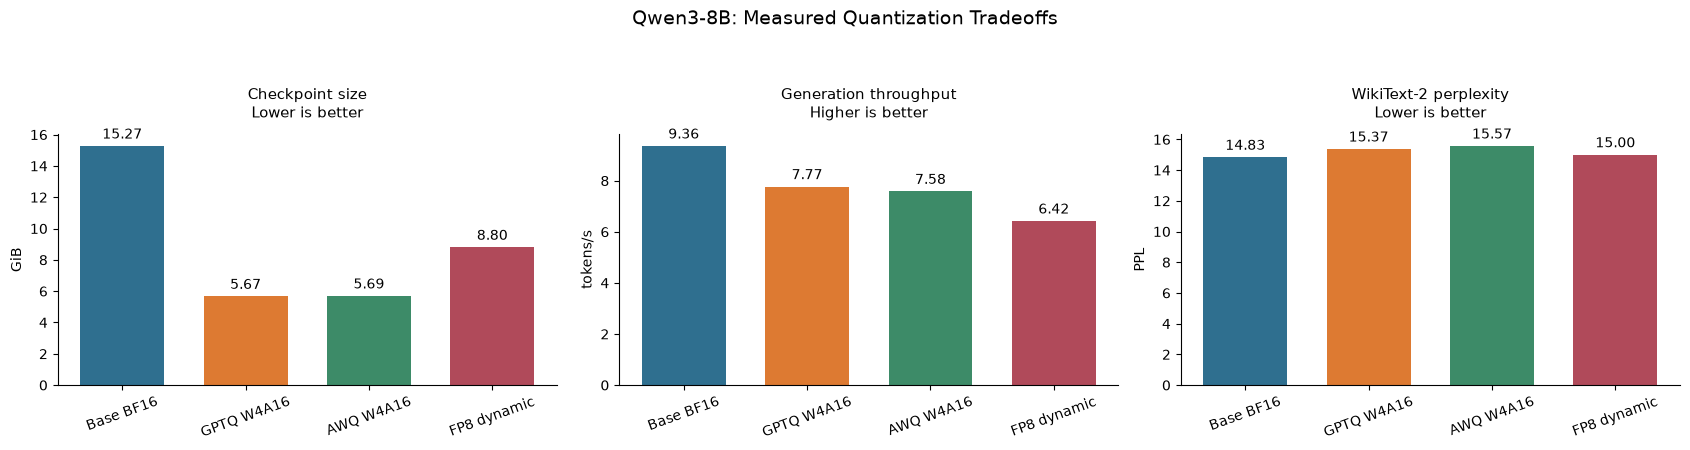

GPTQ W4A16: storage -62.9%, throughput -17.0%, perplexity +3.6%
AWQ W4A16: storage -62.7%, throughput -19.0%, perplexity +4.9%
FP8 dynamic: storage -42.4%, throughput -31.4%, perplexity +1.1%


In [14]:
import matplotlib.pyplot as plt

labels = [result["method"] for result in comparison_results]
sizes_gib = [result["size_gib"] for result in comparison_results]
throughput = [result["tokens_per_second"] for result in comparison_results]
perplexity = [result["perplexity"] for result in comparison_results]
color_by_method = {
    "Base BF16": "#2f6f8f",
    "GPTQ W4A16": "#dd7a32",
    "AWQ W4A16": "#3d8b68",
    "FP8 dynamic": "#b04a5a",
}
colors = [color_by_method[label] for label in labels]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
metrics = [
    (sizes_gib, "Checkpoint size", "GiB", "Lower is better"),
    (throughput, "Generation throughput", "tokens/s", "Higher is better"),
    (perplexity, "WikiText-2 perplexity", "PPL", "Lower is better"),
]

for axis, (values, title, unit, direction) in zip(axes, metrics):
    bars = axis.bar(labels, values, color=colors, width=0.68)
    axis.set_title(f"{title}\n{direction}", fontsize=11, pad=12)
    axis.set_ylabel(unit)
    axis.bar_label(bars, labels=[f"{value:.2f}" for value in values], padding=3)
    axis.tick_params(axis="x", labelrotation=20)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle("Qwen3-8B: Measured Quantization Tradeoffs", fontsize=14, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

base_result = comparison_results[0]
for result in comparison_results[1:]:
    storage_change = (result["size_gib"] / base_result["size_gib"] - 1) * 100
    throughput_change = (result["tokens_per_second"] / base_result["tokens_per_second"] - 1) * 100
    perplexity_change = (result["perplexity"] / base_result["perplexity"] - 1) * 100
    print(
        f"{result['method']}: storage {storage_change:+.1f}%, "
        f"throughput {throughput_change:+.1f}%, perplexity {perplexity_change:+.1f}%"
    )

## Summary

In this notebook, you:

- Learned how LLM Compressor **`oneshot`** applies post-training quantization
- Built GPTQ W4A16, AWQ W4A16, and dynamic FP8 recipes from the same base model
- Compared checkpoint size, generation throughput, and WikiText-2 perplexity using the same measurement path
- Plotted only methods with available, measured checkpoints so missing results are never presented as estimates

## Resources

- [LLM Compressor GitHub](https://github.com/vllm-project/llm-compressor)
- [LLM Compressor Docs](https://docs.vllm.ai/projects/llm-compressor/en/latest/)

- [LLM Compressor GitHub](https://github.com/vllm-project/llm-compressor)
- [LLM Compressor Docs](https://docs.vllm.ai/projects/llm-compressor/en/latest/)